# Prediksi Kualitas Kopi Menggunakan Machine Learning pada Coffee Quality Dataset

### Deskripsi Singkat Tugas
Proyek ini merupakan implementasi machine learning end-to-end menggunakan dataset Coffe Quality Database from CQI. Tujuan utama proyek adalah membangun model machine learning untuk memprediksi kualitas kopi berdasarkan karakteristik sensorik dan atribut produksi kopi.

## Problem Statement
Kualitas kopi merupakan faktir penting dalam industri mopi karena mempengaruhi harga jual dan kepuasan konsumen. Penilaian kualitas kopi biasanya dilakukan secara manual melalui evaluasi sensorik seperti aroma, flavor, acidity, body, dan karakteristik lainnya.
Namu, proses penilaian manual membuthkan waktu dan tenaga ahli. Oleh karena itu, diperlukan pendekatan berbasis machine learning untuk membantu memprediksi kualitas kopi secara otomatis berdasarkan karakteristik yang dimiliki kopi tersebut.

## Import Library

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Load Dataset

In [49]:
df = pd.read_csv('data/merged_data_cleaned.csv')

# melihat 5 data pertama
df.head()

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1339 non-null   int64  
 1   Species                1339 non-null   object 
 2   Owner                  1332 non-null   object 
 3   Country.of.Origin      1338 non-null   object 
 4   Farm.Name              980 non-null    object 
 5   Lot.Number             276 non-null    object 
 6   Mill                   1021 non-null   object 
 7   ICO.Number             1180 non-null   object 
 8   Company                1130 non-null   object 
 9   Altitude               1113 non-null   object 
 10  Region                 1280 non-null   object 
 11  Producer               1107 non-null   object 
 12  Number.of.Bags         1339 non-null   int64  
 13  Bag.Weight             1339 non-null   object 
 14  In.Country.Partner     1339 non-null   object 
 15  Harv

In [51]:
#statistic dasar
df.describe()

,Unnamed: 0,Number.of.Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Category.Two.Defects,altitude_low_meters,altitude_high_meters,altitude_mean_meters
count,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1338.000000,1339.000000,1109.000000,1109.000000,1109.000000
mean,669.000000,154.182972,7.566706,7.520426,7.401083,7.535706,7.517498,7.518013,9.834877,9.835108,9.856692,7.503376,82.089851,0.088379,0.479462,0.173393,3.556385,1750.713315,1799.347775,1775.030545
std,386.680316,129.987162,0.377560,0.398442,0.404463,0.379827,0.370064,0.408943,0.554591,0.763946,0.616102,0.473464,3.500575,0.048287,2.549683,0.832121,5.312541,8669.440545,8668.805771,8668.626080
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,334.500000,14.000000,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,10.000000,10.000000,10.000000,7.250000,81.080000,0.090000,0.000000,0.000000,0.000000,1100.000000,1100.000000,1100.000000
50%,669.000000,175.000000,7.580000,7.580000,7.420000,7.580000,7.500000,7.500000,10.000000,10.000000,10.000000,7.500000,82.500000,0.110000,0.000000,0.000000,2.000000,1310.640000,1350.000000,1310.640000
75%,1003.500000,275.000000,7.750000,7.750000,7.580000,7.750000,7.670000,7.750000,10.000000,10.000000,10.000000,7.750000,83.670000,0.120000,0.000000,0.000000,4.000000,1600.000000,1650.000000,1600.000000
max,1338.000000,1062.000000,8.750000,8.830000,8.670000,8.750000,8.580000,8.750000,10.000000,10.000000,10.000000,10.000000,90.580000,0.280000,63.000000,11.000000,55.000000,190164.000000,190164.000000,190164.000000


In [52]:
#cari missing value
df.isnull().sum()

Unnamed: 0                  0
Species                     0
Owner                       7
Country.of.Origin           1
Farm.Name                 359
Lot.Number               1063
Mill                      318
ICO.Number                159
Company                   209
Altitude                  226
Region                     59
Producer                  232
Number.of.Bags              0
Bag.Weight                  0
In.Country.Partner          0
Harvest.Year               47
Grading.Date                0
Owner.1                     7
Variety                   226
Processing.Method         170
Aroma                       0
Flavor                      0
Aftertaste                  0
Acidity                     0
Body                        0
Balance                     0
Uniformity                  0
Clean.Cup                   0
Sweetness                   0
Cupper.Points               0
Total.Cup.Points            0
Moisture                    0
Category.One.Defects        0
Quakers   

## Drop Column yang tidak terpakai

In [53]:
drop_columns = [
    'Unnamed: 0',
    'Owner',
    'Farm.Name',
    'Lot.Number',
    'Mill',
    'ICO.Number',
    'Company',
    'Producer',
    'Owner.1',
    'Certification.Address',
    'Certification.Contact'
]

df = df.drop(columns=drop_columns)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Species               1339 non-null   object 
 1   Country.of.Origin     1338 non-null   object 
 2   Altitude              1113 non-null   object 
 3   Region                1280 non-null   object 
 4   Number.of.Bags        1339 non-null   int64  
 5   Bag.Weight            1339 non-null   object 
 6   In.Country.Partner    1339 non-null   object 
 7   Harvest.Year          1292 non-null   object 
 8   Grading.Date          1339 non-null   object 
 9   Variety               1113 non-null   object 
 10  Processing.Method     1169 non-null   object 
 11  Aroma                 1339 non-null   float64
 12  Flavor                1339 non-null   float64
 13  Aftertaste            1339 non-null   float64
 14  Acidity               1339 non-null   float64
 15  Body                 

## Handle Missing Value

In [55]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [56]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [57]:
#mengecek apakah masih ada missing value
df.isnull().sum()

Species                 0
Country.of.Origin       0
Altitude                0
Region                  0
Number.of.Bags          0
Bag.Weight              0
In.Country.Partner      0
Harvest.Year            0
Grading.Date            0
Variety                 0
Processing.Method       0
Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Uniformity              0
Clean.Cup               0
Sweetness               0
Cupper.Points           0
Total.Cup.Points        0
Moisture                0
Category.One.Defects    0
Quakers                 0
Color                   0
Category.Two.Defects    0
Expiration              0
Certification.Body      0
unit_of_measurement     0
altitude_low_meters     0
altitude_high_meters    0
altitude_mean_meters    0
dtype: int64

## Eda (Visualisasi)

### Distribusi Target

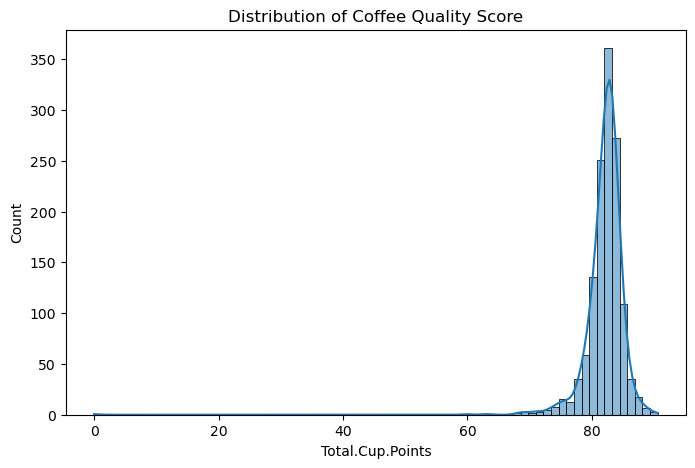

In [58]:
# melihat distribusi kualitas kopi, apakah normal, apakah ada outlier.
plt.figure(figsize=(8,5))
sns.histplot(df['Total.Cup.Points'], kde=True)
plt.title('Distribution of Coffee Quality Score')
plt.show()

### Korelasi

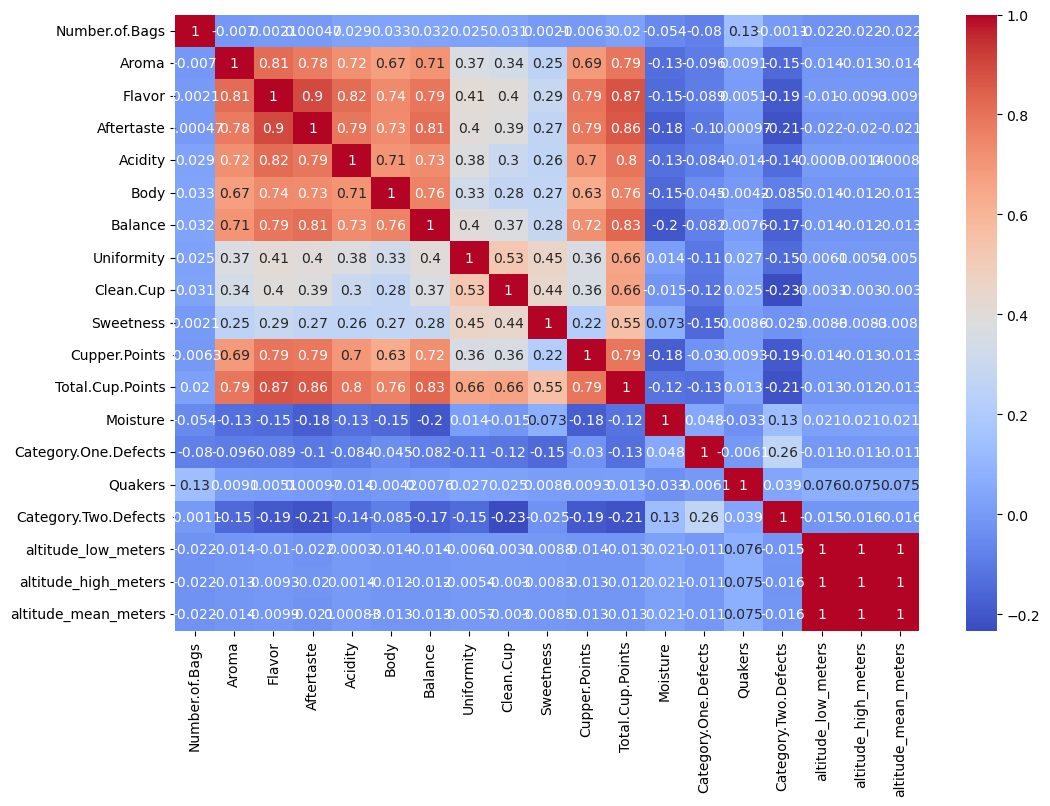

In [59]:
# fitur mana paling berhubungan dengan kualitas kopi.
plt.figure(figsize=(12,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

### Scatterplot

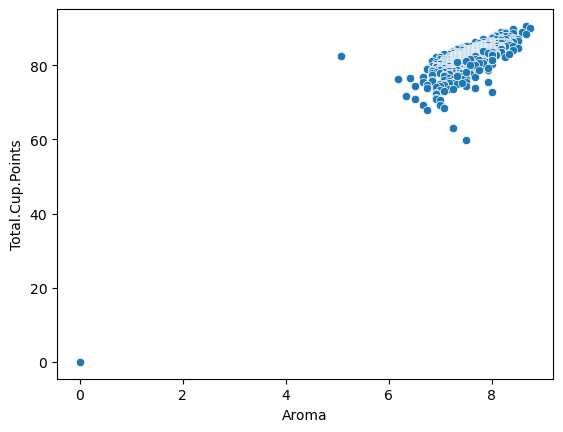

In [60]:
sns.scatterplot(
    x='Aroma',
    y='Total.Cup.Points',
    data=df
)

plt.show()

### Boxplot

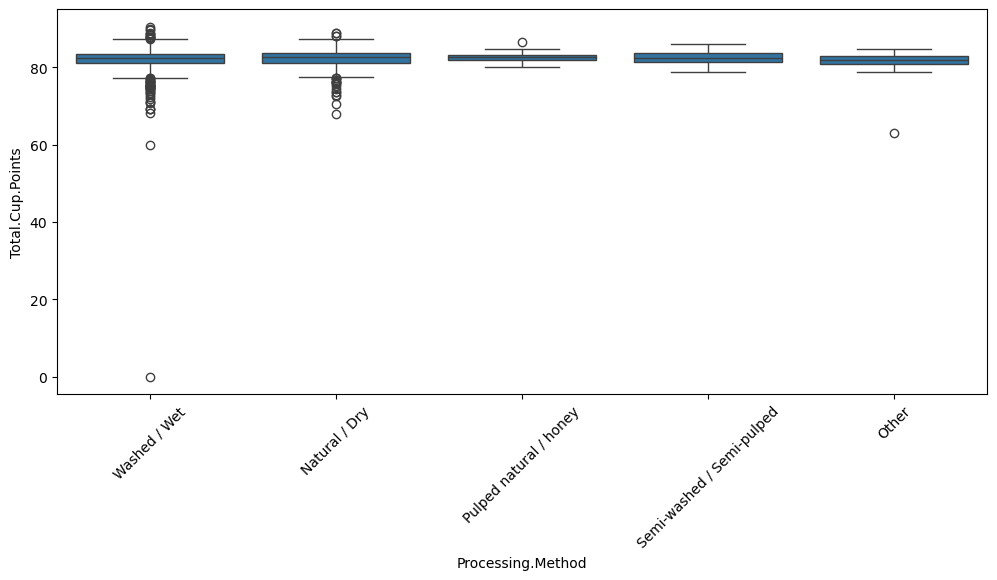

In [61]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x='Processing.Method',
    y='Total.Cup.Points',
    data=df
)

plt.xticks(rotation=45)
plt.show()

## Outlier Detection

In [62]:
Q1 = df['Total.Cup.Points'].quantile(0.25)
Q3 = df['Total.Cup.Points'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

77.195
87.555


## Cari Outlier

In [63]:
outlier = df[
    (df['Total.Cup.Points'] < lower_bound) |
    (df['Total.Cup.Points'] > upper_bound)
]

outlier

,Species,Country.of.Origin,Altitude,Region,Number.of.Bags,Bag.Weight,In.Country.Partner,Harvest.Year,Grading.Date,Variety,...,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,Arabica,Ethiopia,1950-2200,guji-hambela,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",Caturra,...,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,m,1950.00,2200.00,2075.00
1,Arabica,Ethiopia,1950-2200,guji-hambela,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",Other,...,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,m,1950.00,2200.00,2075.00
2,Arabica,Guatemala,1600 - 1800 m,huila,5,1,Specialty Coffee Association,2012,"May 31st, 2010",Bourbon,...,0,0.0,Green,0,"May 31st, 2011",Specialty Coffee Association,m,1600.00,1800.00,1700.00
3,Arabica,Ethiopia,1800-2200,oromia,320,60 kg,METAD Agricultural Development plc,2014,"March 26th, 2015",Caturra,...,0,0.0,Green,2,"March 25th, 2016",METAD Agricultural Development plc,m,1800.00,2200.00,2000.00
4,Arabica,Ethiopia,1950-2200,guji-hambela,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",Other,...,0,0.0,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,m,1950.00,2200.00,2075.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1309,Arabica,Guatemala,4650,nuevo oriente,275,1 kg,Asociacion Nacional Del Café,2012,"May 24th, 2012",Catuai,...,0,0.0,Green,4,"May 24th, 2013",Asociacion Nacional Del Café,ft,1417.32,1417.32,1417.32
1310,Arabica,Honduras,1400,comayagua,275,69 kg,Instituto Hondureño del Café,2017,"April 28th, 2017",Caturra,...,0,0.0,Green,2,"April 28th, 2018",Instituto Hondureño del Café,m,1400.00,1400.00,1400.00
1336,Robusta,United States,795 meters,"kwanza norte province, angola",1,1 kg,Specialty Coffee Association,2014,"December 23rd, 2014",Caturra,...,0,0.0,Green,6,"December 23rd, 2015",Specialty Coffee Association,m,795.00,795.00,795.00
1337,Robusta,India,1100,huila,1,5 lbs,Specialty Coffee Association,2013,"August 25th, 2014",Caturra,...,20,0.0,Green,1,"August 25th, 2015",Specialty Coffee Association,m,1310.64,1350.00,1310.64


## Hapus Outlier

In [17]:
df = df[
    (df['Total.Cup.Points'] >= lower_bound) &
    (df['Total.Cup.Points'] <= upper_bound)
]

## Memisahkan Feature & Target

In [18]:
X = df.drop('Total.Cup.Points', axis=1)
y = df['Total.Cup.Points']

## Pisahkan Feature Numeric & Categorical

In [19]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

## Encoding + Scaling

### Buat Preprocessor

In [20]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# StandardScaler digunakan untuk menstabilkan fitur numerik dan membantu model linear
# OneHotEncoder digunakan karena fitur kategorikal tidak punya urutan dan cocok untuk niminal category

## Split Data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Pertama

### Linear Regression

In [22]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

### Train Model

In [23]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Predict

In [24]:
y_pred_lr = lr_pipeline.predict(X_test)

## Evaluasi Model

In [25]:
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R2 :", r2)

MSE : 0.000305868923726263
RMSE : 0.017489108717320703
MAE : 0.013360372497681086
R2 : 0.9999051915204537


## Random Forest Regressor

### Pipeline Random Forest

In [26]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

### Train Random Forest

In [27]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Predict

In [28]:
y_pred_rf = rf_pipeline.predict(X_test)

### Evaluasi Random Forest

In [29]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("MAE :", mae_rf)
print("R2 :", r2_rf)

MSE : 0.1260235549606293
RMSE : 0.35499796472744644
MAE : 0.23601496062992092
R2 : 0.9609371835252705


### Bandingkan Model

In [30]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse, rmse_rf],
    'MAE': [mae, mae_rf],
    'R2': [r2, r2_rf]
})

comparison

,Model,RMSE,MAE,R2
0,Linear Regression,0.017489,0.013360,0.999905
1,Random Forest,0.354998,0.236015,0.960937


## Cek Overfitting

### Train Kedua Model

In [31]:
train_score_lr = lr_pipeline.score(X_train, y_train)
test_score_lr = lr_pipeline.score(X_test, y_test)

train_score_rf = rf_pipeline.score(X_train, y_train)
test_score_rf = rf_pipeline.score(X_test, y_test)

print("Train R2:", train_score_lr)
print("Test R2:", test_score_lr)

print("Train R2:", train_score_rf)
print("Test R2:", test_score_rf)

Train R2: 0.9999980538288551
Test R2: 0.9999051915204537
Train R2: 0.9885676432879447
Test R2: 0.9609371835252705


## Cross Validation

In [32]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Cross Validation Linear Regression

In [33]:
cv_lr = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=kf,
    scoring='r2'
)

### Cross Validation Random Forest

In [34]:
cv_rf = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=kf,
    scoring='r2'
)

In [35]:
cv_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Mean R2': [cv_lr.mean(), cv_rf.mean()],
    'Std Dev': [cv_lr.std(), cv_rf.std()]
})

cv_results

,Model,Mean R2,Std Dev
0,Linear Regression,0.999638,0.000401
1,Random Forest,0.930395,0.015442


## HyperParameter Tuning

In [36]:
#parameter grid
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

#grid search
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

#train
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [37]:
#Best Parameter
print(grid_search.best_params_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [175]:
#Best Score
print(grid_search.best_score_)

0.9149717893637463


### Parameter Grid

In [38]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

### Grid Search

In [39]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [40]:
#train
grid_search.fit(X_train, y_train)

#best parameter
print(grid_search.best_params_)

#best score
print(grid_search.best_score_)


#Evaluasi setelah tuning
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)
print("Tuned R2:", r2_tuned)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.9154626501916822
Tuned R2: 0.9621170161307403


## Feature Engineering

In [41]:
#buat fitur baru
df['altitude_category'] = pd.cut(
    df['altitude_mean_meters'],
    bins=[0,1000,1500,2000,3000],
    labels=['low','medium','high','very_high']
)

In [42]:
df[['altitude_mean_meters', 'altitude_category']].head()

,altitude_mean_meters,altitude_category
16,1500.00,medium
17,1310.64,medium
18,1450.00,medium
19,1850.00,high
20,2019.00,very_high


### Ulang Proses ML

In [43]:
X = df.drop('Total.Cup.Points', axis=1)
y = df['Total.Cup.Points']

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns

#preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
best_model.fit(X_train, y_train)
y_pred_fe = best_model.predict(X_test)

r2_fe = r2_score(y_test, y_pred_fe)

print(r2_fe)

0.9621170161307403


### Bandingkan Sebelum VS Sesudah Feature Engineering

In [45]:
fe_comparison = pd.DataFrame({
    'Condition': ['Before Feature Engineering', 'After Feature Engineering'],
    'R2': [r2_rf, r2_fe]
})

fe_comparison

,Condition,R2
0,Before Feature Engineering,0.960937
1,After Feature Engineering,0.962117


## Kesimpulan
Berdasarkan hasil proyek machine learning yang telah dilakukan, diperoleh beberapa kesimpulan.
1. Dataset Coffee Quality Database from CQI berhaisl digunaakn untuk membangun model prediksi kualitas kopi.
2. Fitur sensorik seperti aroma, flavor, dan lain lain memiliki pengaruh besar terhadap nilai kualitas kopi.
3. Model Linear Regression memberikan performa terbaik.
4. Model Random Forest juga memberikan performa yang sangat baik, namun disedikit mengalami overfitting dibandingkan dengan Linear Regression.
5. Hasil cross validation memiliki performa stabil.
6. Hyperparameter tuning dan feature engineering sedikit meningkatkan kualitas model.
## Saran
1. Menggunakan dataset dengan jumlah yang kebih besar dan beragam.
2. Menggunakan algoritma ML lain seperti XGBoost. Gradient Boosting.
3. Menambahkan analisis clustering untuk melakukan segmentasi kualitas kopi berdasarkan karakteristik tertentu.
4. Mengembangkan sistem prediksi kualitas kopi berbasis web.
5. Menambahkan fitur lain.